# F1 Race Data Analysis
**Martin Adebayo · Magd Aref · Johann Cubillo**

Data: [Formula 1 Race Dataset (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)

---
## Table of contents
1. [Setup & data loading](#setup)
2. [Data cleaning](#cleaning)
3. [Pit stop strategy](#pit-stops)
4. [Circuit clustering](#clustering)
5. [Grid vs finishing position](#grid-finish)
6. [Race result predictor (ML)](#ml)
7. [DNF prediction](#dnf)
8. [Constructor standings](#constructors)
9. [Driver careers](#careers)
10. [Lap time trends](#lap-times)
11. [Qualifying improvement](#qualifying)
12. [Lap 1 analysis](#lap1)
13. [Summary](#summary)


---
## 1. Setup & data loading 


In [524]:
# --- Libraries ---
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt 
import seaborn as sns         
from scipy import stats      
import warnings
warnings.filterwarnings('ignore')

# Make charts look a bit cleaner
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

results       = pd.read_csv('./' + 'results.csv')
races         = pd.read_csv('./' + 'races.csv')
drivers       = pd.read_csv('./' + 'drivers.csv')
constructors  = pd.read_csv('./' + 'constructors.csv')
circuits      = pd.read_csv('./' + 'circuits.csv')
status        = pd.read_csv('./' + 'status.csv')
standings     = pd.read_csv('./' + 'driver_standings.csv')
con_standings = pd.read_csv('./' + 'constructor_standings.csv')
pit_stops     = pd.read_csv('./' + 'pit_stops.csv')
lap_times     = pd.read_csv('./' + 'lap_times.csv')

print(f"results: {len(results):,} rows")
print(f"lap_times: {len(lap_times):,} rows")


results: 27,304 rows
lap_times: 618,766 rows


In [525]:
df = results.copy()

# Add year, round, and circuit information from the races table
df = df.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')

# Add driver name
df = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
df['driver'] = df['forename'] + ' ' + df['surname']

# Add team (constructor) name
df = df.merge(constructors[['constructorId', 'name']], on='constructorId')

# Add retirement reason (status)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Convert columns that should be numbers
for col in ['grid', 'positionOrder', 'points']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a full-name column for the constructor
df = df.rename(columns={'name': 'team'})


# DNF = Did Not Finish. Cars that are "lapped" (+1 Lap etc.) did finish — only
# mechanical failures and crashes count as DNFs.
lapped   = df['status'].str.startswith('+')   # e.g. "+1 Lap"
finished = df['statusId'] == 1                 # "Finished"
df['dnf']    = (~(finished | lapped)).astype(int)   # 1 = retired, 0 = finished
df['win']    = (df['positionOrder'] == 1).astype(int)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# keep rows where the driver actually started from the grid
base = df[df['grid'] > 0].copy()
base['pos_change'] = base['grid'] - base['positionOrder']  # positive = gained places

print(f"Working table: {len(base):,} race starts")
print(base[['driver', 'team', 'year', 'grid', 'positionOrder', 'pos_change', 'dnf']].head())


Working table: 25,646 race starts
              driver        team  year  grid  positionOrder  pos_change  dnf
0     Lewis Hamilton     McLaren  2008   1.0              1         0.0    0
1      Nick Heidfeld  BMW Sauber  2008   5.0              2         3.0    0
2       Nico Rosberg    Williams  2008   7.0              3         4.0    0
3    Fernando Alonso     Renault  2008  11.0              4         7.0    0
4  Heikki Kovalainen     McLaren  2008   3.0              5        -2.0    0


---
## 2. Data cleaning 


In [526]:
print(results.dtypes)
print()

CSV_NULL = '\\N'

print("Null values:")
for col in results.columns:
    n = (results[col] == CSV_NULL).sum()

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                object
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

Null values:


In [527]:
# Identfying Null values

results      = pd.read_csv('./' + 'results.csv',     na_values=CSV_NULL)
races        = pd.read_csv('./' + 'races.csv',       na_values=CSV_NULL)
drivers      = pd.read_csv('./' + 'drivers.csv',     na_values=CSV_NULL)
constructors = pd.read_csv('./' + 'constructors.csv',na_values=CSV_NULL)
circuits     = pd.read_csv('./' + 'circuits.csv',    na_values=CSV_NULL)
status       = pd.read_csv('./' + 'status.csv',      na_values=CSV_NULL)
qualifying   = pd.read_csv('./' + 'qualifying.csv',  na_values=CSV_NULL)
pit_stops    = pd.read_csv('./' + 'pit_stops.csv',   na_values=CSV_NULL)
lap_times    = pd.read_csv('./' + 'lap_times.csv',   na_values=CSV_NULL)

# Verify: the '\\N' values should now show up as NaN
missing = results.isnull().sum()
missing = missing[missing > 0]
#The 'position' column has " + missing['position'] + " missing values — these are DNFs
print(missing)

number                 6
grid                  20
position           10953
time               19252
milliseconds       19252
fastestLap         18535
rank               18277
fastestLapTime     18535
fastestLapSpeed    19052
dtype: int64


In [528]:
# Convert the columns we need
for col in ['grid', 'positionOrder', 'points', 'laps']:
    results[col] = pd.to_numeric(results[col], errors='coerce')

# pit_stops milliseconds is also stored as text
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

In [529]:
# Outlier removal: lap times slower than 150% of the race median are not
# representative of true racing pace (safety car / VSC periods, in/out-laps
# around pit stops, damaged cars). No lower bound needed — transponder data
# won't contain erroneously fast laps.

min_lap = lap_times['milliseconds'].min() / 1000
max_lap = lap_times['milliseconds'].max() / 1000
slow_lap_count = (lap_times['milliseconds'] > 300_000).sum()
worst = lap_times.nlargest(3, 'milliseconds')[['raceId', 'driverId', 'lap', 'milliseconds']]
worst['seconds'] = worst['milliseconds'] / 1000

race_median = lap_times.groupby('raceId')['milliseconds'].median().rename('race_med')
lap_times = lap_times.drop(columns=['race_med'], errors='ignore').join(race_median, on='raceId')
lap_times_clean = lap_times[
    lap_times['milliseconds'] < lap_times['race_med'] * 1.50
].copy()

removed = len(lap_times) - len(lap_times_clean)
pct_removed = removed / len(lap_times) * 100
kept = len(lap_times_clean)

print(
f"""Lap time range: {min_lap:.1f}s – {max_lap:.1f}s
Laps over 5 min: {slow_lap_count:,}
Top 3 slowest:
{worst.to_string(index=False)}
Removed (>150% median): {removed:,} ({pct_removed:.2f}%) | Kept: {kept:,}
"""
)


Lap time range: 55.4s – 7507.5s
Laps over 5 min: 710
Top 3 slowest:
 raceId  driverId  lap  milliseconds  seconds
    847         2   25       7507547 7507.547
    847        13   25       7506656 7506.656
    847       808   25       7506243 7506.243
Removed (>150% median): 12,498 (2.02%) | Kept: 606,268



In [530]:
# Invaild Rows — grid position = 0

# Results table show some drivers have grid = 0.
# This means they started from the pit lane (outside the normal grid),
grid_zero = results[results['grid'] == 0]
grid_zero_with_status = grid_zero.merge(status, on='statusId')

In [531]:
# A duplicate row means the same driver appears twice in the same race —
# which shouldn't happen. These usually come from pre-qualifying in older
# seasons where a driver made multiple attempts. Keep only the first entry.

results = results.drop_duplicates(subset=['raceId', 'driverId'], keep='first')

---
## 3. Pit stop strategy

**Question:** Does the number of pit stops affect how many places a driver gains or loses?

We use **position change** (starting grid − finishing position) as our outcome.  
A positive number means the driver moved forward; negative means they fell back.

We test three common strategies: 1-stop, 2-stop, and 3+ stops.


In [532]:
# Summarise pit stop data per driver per race
pit_stops['ms_num'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

pit_summary = (
    pit_stops
    .groupby(['raceId', 'driverId'])
    .agg(
        num_stops    = ('stop', 'count'),        # how many stops?
        avg_pit_ms   = ('ms_num', 'mean'),        # average stop duration
        first_stop_lap = ('lap', 'min')           # which lap was the first stop?
    )
    .reset_index()
)

# merge pit info onto our main table
df_pit = base.merge(pit_summary, on=['raceId', 'driverId'], how='left')

# Label each driver's strategy
df_pit['strategy'] = df_pit['num_stops'].map({
    1: '1-stop',
    2: '2-stop',
    3: '3+ stops'
})

# keep rows with a known strategy (1, 2, or 3+ stops)
ORDER    = ['1-stop', '2-stop', '3+ stops']
df_strat = df_pit[df_pit['strategy'].isin(ORDER)].copy()

print(df_strat['strategy'].value_counts())


strategy
2-stop      5022
1-stop      3716
3+ stops    1899
Name: count, dtype: int64


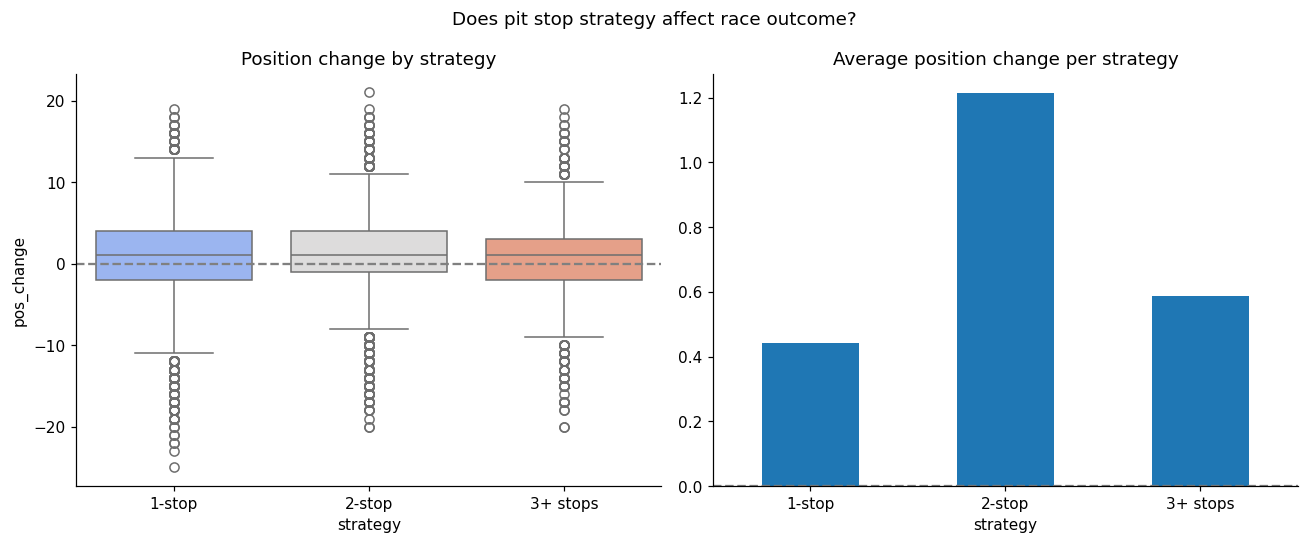

In [533]:
# Graph position change by strategy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Does pit stop strategy affect race outcome?')

sns.boxplot(data=df_strat, x='strategy', y='pos_change',
            order=ORDER, palette='coolwarm', ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Position change by strategy')

avg = df_strat.groupby('strategy')['pos_change'].mean().reindex(ORDER)
avg.plot.bar(ax=axes[1], rot=0)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Average position change per strategy')

plt.tight_layout()
plt.show()


---
## 4. Circuit clustering 

**Question:** Can we group F1 circuits into types based on how races tend to play out?

**KMeans clustering** finds groups of similar items. We describe each circuit with three simple race stats and let the algorithm do the rest.

**Features used:**
- Average number of pit stops per driver (tyre wear / strategy)
- Average position change (overtaking difficulty)
- DNF rate (how punishing the track is)


In [534]:
# Average pit stops per driver per circuit
pit_per_circuit = (
    pit_stops
    .merge(races[['raceId', 'circuitId']], on='raceId')
    .groupby('circuitId')['stop']
    .mean()
    .rename('avg_stops')
    .reset_index()
)

# Average position change & DNF rate per circuit
race_stats = (
    base
    .groupby('circuitId')
    .agg(
        avg_pos_change=('pos_change', 'mean'),
        dnf_rate=('dnf', 'mean')
    )
    .reset_index()
)

# Merge into one table
circ_feats = (
    circuits[['circuitId', 'name']]
    .merge(pit_per_circuit, on='circuitId', how='left')
    .merge(race_stats,      on='circuitId', how='left')
    .dropna()
)

FEATURES = ['avg_stops', 'avg_pos_change', 'dnf_rate']
print(f'Circuits with enough data: {len(circ_feats)}')
print(circ_feats[FEATURES].describe().round(3))


Circuits with enough data: 43
       avg_stops  avg_pos_change  dnf_rate
count     43.000          43.000    43.000
mean       1.667          -0.011     0.319
std        0.304           0.069     0.136
min        1.156          -0.206     0.050
25%        1.526          -0.018     0.175
50%        1.683           0.000     0.360
75%        1.760           0.004     0.441
max        3.015           0.271     0.585


In [535]:
# Fit the final model (k=3 chosen by trial and error)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale features so each one carries equal weight
X = StandardScaler().fit_transform(circ_feats[FEATURES].values)

# We tried different values of k and found k=3 gives the most meaningful groups
K_FINAL = 3
circ_feats['cluster'] = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10).fit_predict(X)


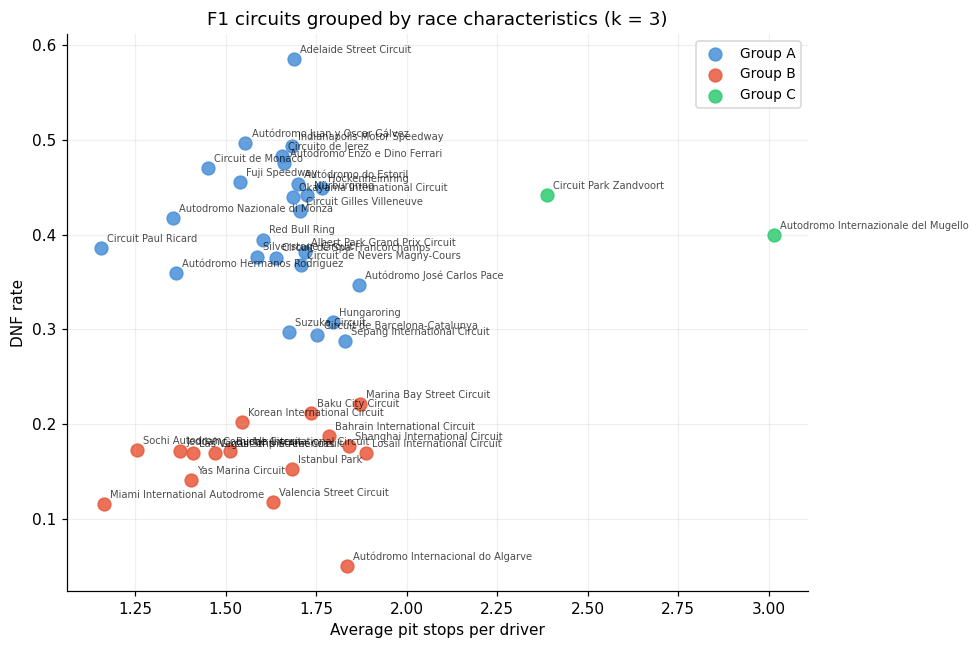

In [536]:
# Scatter: avg stops vs DNF rate 
CLUSTER_NAMES = {0: 'Group A', 1: 'Group B', 2: 'Group C'}
palette = ['#4A90D9', '#E8593C', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_FINAL):
    mask = circ_feats['cluster'] == c
    ax.scatter(
        circ_feats.loc[mask, 'avg_stops'],
        circ_feats.loc[mask, 'dnf_rate'],
        s=70, label=CLUSTER_NAMES[c], color=palette[c], alpha=0.85
    )
    # Label each point with the circuit name
    for _, row in circ_feats[mask].iterrows():
        ax.annotate(row['name'], (row['avg_stops'], row['dnf_rate']),
                    fontsize=6.5, alpha=0.7, xytext=(4, 4),
                    textcoords='offset points')

ax.set_xlabel('Average pit stops per driver')
ax.set_ylabel('DNF rate')
ax.set_title(f'F1 circuits grouped by race characteristics (k = {K_FINAL})')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 5. Grid position vs finishing position

**Question:** How strongly does your qualifying position predict where you finish?

We calculate the **correlation** between grid and finishing position to find out.
We also look at how this has changed across different eras of the sport.


In [537]:
# Correlation between grid and finishing position
# Interpretation: moderate positive correlation — starting further back
# is associated with finishing further back.
corr = base['grid'].corr(base['positionOrder'])

print("Correlation (grid vs finish):", round(corr, 3))

# Pole position win rate
pole_races  = base[base['grid'] == 1]
pole_win_rt = (pole_races['positionOrder'] == 1).mean() * 100
print("Pole position -> race win:", round(pole_win_rt, 1), "% of the time")

# Podium rates by grid band
print()
print("Podium (top 3) rate by starting position:")
for label, lo, hi in [('P1-3', 1, 3), ('P4-6', 4, 6),
                       ('P7-10', 7, 10), ('P11-15', 11, 15), ('P16+', 16, 40)]:
    sub  = base[(base['grid'] >= lo) & (base['grid'] <= hi)]
    rate = (sub['positionOrder'] <= 3).mean() * 100
    print("  Grid " + label + ": " + str(round(rate, 1)) + "%")


Correlation (grid vs finish): 0.45
Pole position -> race win: 43.0 % of the time

Podium (top 3) rate by starting position:
  Grid P1-3: 55.6%
  Grid P4-6: 25.8%
  Grid P7-10: 9.1%
  Grid P11-15: 3.0%
  Grid P16+: 0.8%


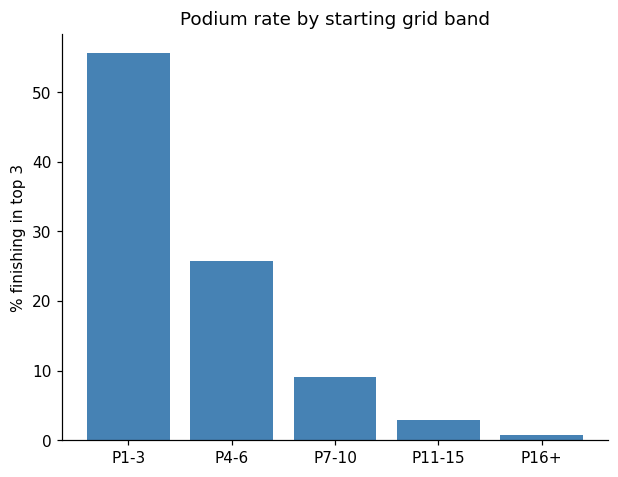

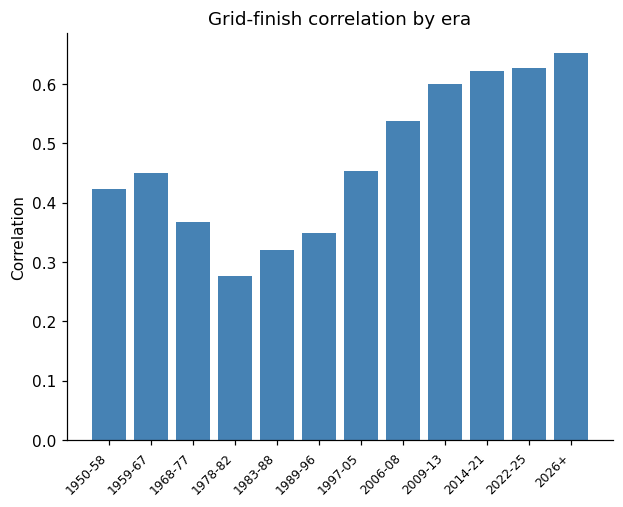

In [538]:
# Has the correlation changed over time?
era_bins   = [1949, 1958, 1966, 1976, 1981, 1987, 1995, 2004, 2007, 2012, 2020, 2024, 2030]
era_labels = ['1950-58', '1959-67', '1968-77', '1978-82', '1983-88',
              '1989-96', '1997-05', '2006-08', '2009-13', '2014-21', '2022-25', '2026+']
base['era'] = pd.cut(base['year'], bins=era_bins, labels=era_labels)

era_corr = (
    base.groupby('era', observed=True)
    .apply(lambda g: g['grid'].corr(g['positionOrder']))
    .reset_index()
)
era_corr.columns = ['era', 'correlation']

# Podium rate by grid band
bands  = ['P1-3', 'P4-6', 'P7-10', 'P11-15', 'P16+']
limits = [(1,3), (4,6), (7,10), (11,15), (16,40)]
rates  = [(base[(base['grid']>=lo)&(base['grid']<=hi)]['positionOrder']<=3).mean()*100
          for lo, hi in limits]

plt.bar(bands, rates, color='steelblue')
plt.title('Podium rate by starting grid band')
plt.ylabel('% finishing in top 3')
plt.show()

# Grid-finish correlation by era — has generally increased over time
plt.bar(era_corr['era'], era_corr['correlation'], color='steelblue')
plt.title('Grid-finish correlation by era')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.show()


---
## 6. Race result predictor (machine learning) <a id='ml'></a>

**Question:** Can we predict where a driver will finish using only information available before the race?

We train a **Decision Tree** using these features:
- Grid position (qualifying result)
- Driver's championship points so far this season
- Constructor's championship points so far this season

**Design choice:** We train on races from 2001–2019 and test on races from 2020 onwards.


In [539]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Driver standings: use points from the previous race
drv = (standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['driverId', 'year', 'round']))
drv['driver_pts_before'] = drv.groupby(['driverId', 'year'])['points'].shift(1).fillna(0)

# Constructor standings: same idea
con = (con_standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['constructorId', 'year', 'round']))
con['con_pts_before'] = con.groupby(['constructorId', 'year'])['points'].shift(1).fillna(0)

# Merge features onto base table
df_ml = (base
         .merge(drv[['raceId', 'driverId', 'driver_pts_before']],
                on=['raceId', 'driverId'], how='left')
         .merge(con[['raceId', 'constructorId', 'con_pts_before']],
                on=['raceId', 'constructorId'], how='left'))

FEATURES = ['grid', 'driver_pts_before', 'con_pts_before']
df_ml = df_ml[FEATURES + ['positionOrder', 'year']].dropna()

# Train/test split by year
train = df_ml[(df_ml['year'] > 2000) & (df_ml['year'] < 2020)]
test  = df_ml[df_ml['year'] >= 2020]

X_train, y_train = train[FEATURES].values, train['positionOrder'].values
X_test,  y_test  = test[FEATURES].values,  test['positionOrder'].values

print("Training rows:", len(X_train), " (races 2001-2019)")
print("Test rows:", len(X_test), " (races 2020+)")


Training rows: 7402  (races 2001-2019)
Test rows: 2607  (races 2020+)


In [540]:
# Fit decision tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

# Baseline: predict everyone finishes where they qualified
baseline_preds = test['grid'].values

# MAE = Mean Absolute Error (average positions off by)
# RMSE = Root Mean Squared Error (penalises large errors more)
tree_mae  = mean_absolute_error(y_test, tree_preds)
base_mae  = mean_absolute_error(y_test, baseline_preds)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_preds))
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("Decision Tree  — MAE:", round(tree_mae, 2), " RMSE:", round(tree_rmse, 2))
print("Baseline (=grid) — MAE:", round(base_mae, 2), " RMSE:", round(base_rmse, 2))


Decision Tree  — MAE: 3.41  RMSE: 4.43
Baseline (=grid) — MAE: 3.43  RMSE: 4.95


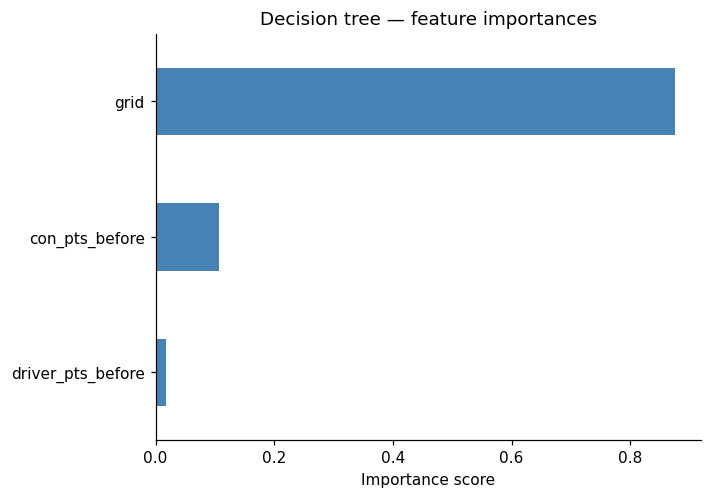

Most important features:
  grid: 0.876
  con_pts_before: 0.107
  driver_pts_before: 0.017


In [541]:
# Which features matter most?
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind='barh', color='steelblue')
plt.title('Decision tree — feature importances')
plt.xlabel('Importance score')
plt.show()

print("Most important features:")
for feat, imp in importances.sort_values(ascending=False).items():
    print("  " + feat + ": " + str(round(imp, 3)))


---
## 7. DNF prediction <a id='dnf'></a>

**Question:** Can we predict whether a driver will retire from the race before it ends?


**The 140 status codes in `status.csv` fall into a few groups:**

| Category | Examples |
|---|---|
| Crash / collision | Accident, Collision, Spun off, Damage |
| Mechanical Failure | Engine, Oil pressure, Overheating, Cooling system |
| Drivetrain | Gearbox, Transmission, Clutch, Driveshaft |
| Electrical / hydraulics | Hydraulics, Electrical, Power Unit, ERS |
| Suspension / aero | Brakes, Suspension, Steering, Front wing |
| Tyre / wheel | Tyre, Puncture, Wheel, Wheel bearing |
| Fuel system | Fuel pressure, Fuel pump, Out of fuel |
| Administrative | Disqualified, Withdrew, Did not qualify |
| Driver / safety | Injured, Fire, Driver unwell |



In [542]:
# Categorieze DNFs by type of failure


def categorise_dnf(s):
    s = str(s)
    if s in ('Accident', 'Collision', 'Spun off', 'Collision damage',
             'Fatal accident', 'Damage', 'Debris'):
        return 'Crash / collision'
    elif s in ('Engine', 'Engine fire', 'Engine misfire', 'Oil pressure', 'Oil leak',
               'Oil pump', 'Oil line', 'Oil pipe', 'Water pressure', 'Water leak',
               'Water pump', 'Water pipe', 'Turbo', 'Supercharger',
               'Cooling system', 'Overheating'):
        return 'Mechanical Failure'
    elif s in ('Gearbox', 'Transmission', 'Clutch', 'Differential',
               'Driveshaft', 'Halfshaft', 'Drivetrain', 'CV joint'):
        return 'Drivetrain'
    elif s in ('Hydraulics', 'Electrical', 'Electronics', 'ERS',
               'Battery', 'Ignition', 'Alternator', 'Power Unit'):
        return 'Electrical / hydraulics'
    elif s in ('Tyre', 'Puncture', 'Tyre puncture', 'Wheel',
               'Wheel nut', 'Wheel rim', 'Wheel bearing'):
        return 'Tyre / wheel'
    elif s in ('Suspension', 'Brakes', 'Steering', 'Front wing', 'Rear wing',
               'Broken wing', 'Handling', 'Brake duct', 'Vibrations',
               'Vibration', 'Chassis'):
        return 'Suspension / aero'
    elif s in ('Fuel', 'Fuel pressure', 'Fuel pump', 'Fuel system',
               'Fuel leak', 'Fuel pipe', 'Out of fuel', 'Refuelling'):
        return 'Fuel system'
    elif s in ('Withdrew', 'Did not qualify', 'Disqualified', 'Excluded',
               'Underweight', 'Not classified', 'Safety concerns', '107% Rule'):
        return 'Administrative'
    elif s in ('Injured', 'Injury', 'Physical', 'Driver unwell', 'Fire', 'Safety'):
        return 'Driver / safety'
    else:
        return 'Other mechanical'

# Apply to the full dataset
base['dnf_category'] = base['status'].apply(categorise_dnf)
# For non-DNFs set to None
base.loc[base['dnf'] == 0, 'dnf_category'] = None

# Look at just the DNF rows from 2010 onwards
dnf_rows = base[(base['dnf'] == 1) & (base['year'] >= 2000)].copy()

print(f"Total DNFs (2010+): {len(dnf_rows):,}")
print()
print("Count by category:")
print(dnf_rows['dnf_category'].value_counts().to_string())


Total DNFs (2010+): 2,362

Count by category:
dnf_category
Crash / collision          896
Mechanical Failure         386
Drivetrain                 247
Electrical / hydraulics    244
Suspension / aero          221
Other mechanical           174
Tyre / wheel                72
Administrative              70
Fuel system                 46
Driver / safety              6


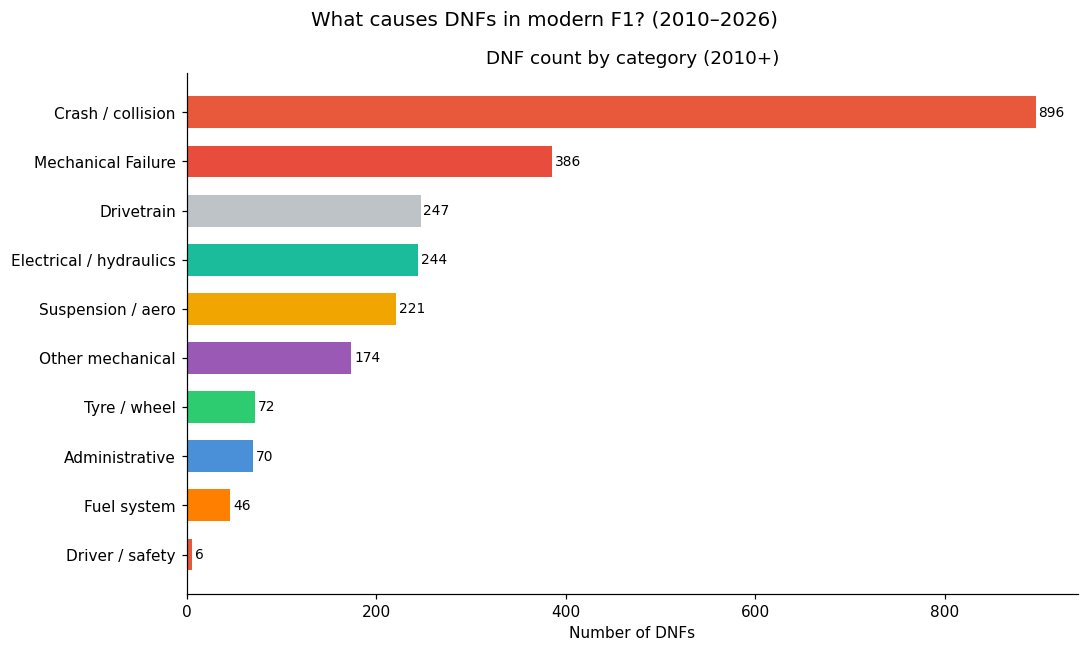

In [543]:
# Chart the DNF categories

cat_counts = dnf_rows['dnf_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('What causes DNFs in modern F1? (2010–2026)', fontsize=13)

# Bar chart — easiest to read exact numbers
colors = ['#E8593C', '#FF8000', '#4A90D9', '#2ECC71',
          '#9B59B6', '#F0A500', '#1ABC9C', '#BDC3C7', '#E74C3C']
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                    color=colors[:len(cat_counts)], height=0.65)
ax.set_xlabel('Number of DNFs')
ax.set_title('DNF count by category (2010+)')
for bar, v in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 str(v), va='center', fontsize=9)


plt.tight_layout()
plt.show()


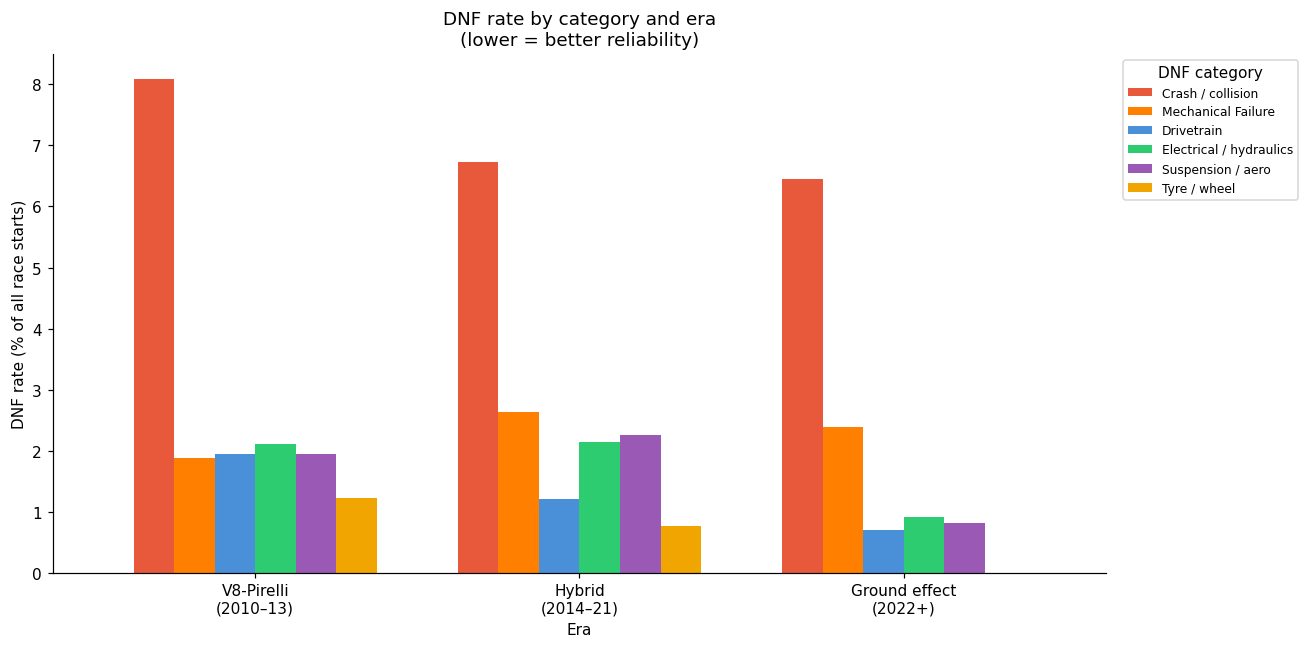

Era DNF rates (% of starts):
dnf_category            Crash / collision  Mechanical Failure  Drivetrain  Electrical / hydraulics  Suspension / aero  Tyre / wheel
era                                                                                                                                
V8-Pirelli\n(2010–13)                8.09                1.88        1.94                     2.11               1.94          1.22
Hybrid\n(2014–21)                    6.72                2.63        1.21                     2.14               2.26          0.77
Ground effect\n(2022+)               6.45                2.39        0.70                     0.92               0.81          0.00


In [544]:
# DNF rates by category and era

dnf_rows['era'] = pd.cut(
    dnf_rows['year'],
    bins=[2009, 2013, 2021, 2027],
    labels=['V8-Pirelli\n(2010–13)', 'Hybrid\n(2014–21)', 'Ground effect\n(2022+)']
)

# Count per era + category, then convert to rates
era_starts = (base[base['year'] >= 2010]
              .groupby(pd.cut(base[base['year']>=2010]['year'],
                              bins=[2009,2013,2021,2027],
                              labels=['V8-Pirelli\n(2010–13)',
                                      'Hybrid\n(2014–21)',
                                      'Ground effect\n(2022+)']),
                       observed=True)
              .size()
              .rename('total_starts'))

era_cat = (dnf_rows.groupby(['era', 'dnf_category'], observed=True)
           .size()
           .unstack(fill_value=0))

# Convert to % of total starts in that era
era_rate = era_cat.div(era_starts, axis=0) * 100

# Focus on the main mechanical categories for clarity
PLOT_CATS = ['Crash / collision', 'Mechanical Failure', 'Drivetrain',
             'Electrical / hydraulics', 'Suspension / aero', 'Tyre / wheel']
era_rate_plot = era_rate[PLOT_CATS]

fig, ax = plt.subplots(figsize=(12, 6))
era_rate_plot.plot(kind='bar', ax=ax, width=0.75,
                   color=['#E8593C','#FF8000','#4A90D9','#2ECC71','#9B59B6','#F0A500'])
ax.set_xlabel('Era')
ax.set_ylabel('DNF rate (% of all race starts)')
ax.set_title('DNF rate by category and era\n(lower = better reliability)')
ax.set_xticklabels(era_rate_plot.index, rotation=0)
ax.legend(title='DNF category', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Era DNF rates (% of starts):")
print(era_rate_plot.round(2).to_string())


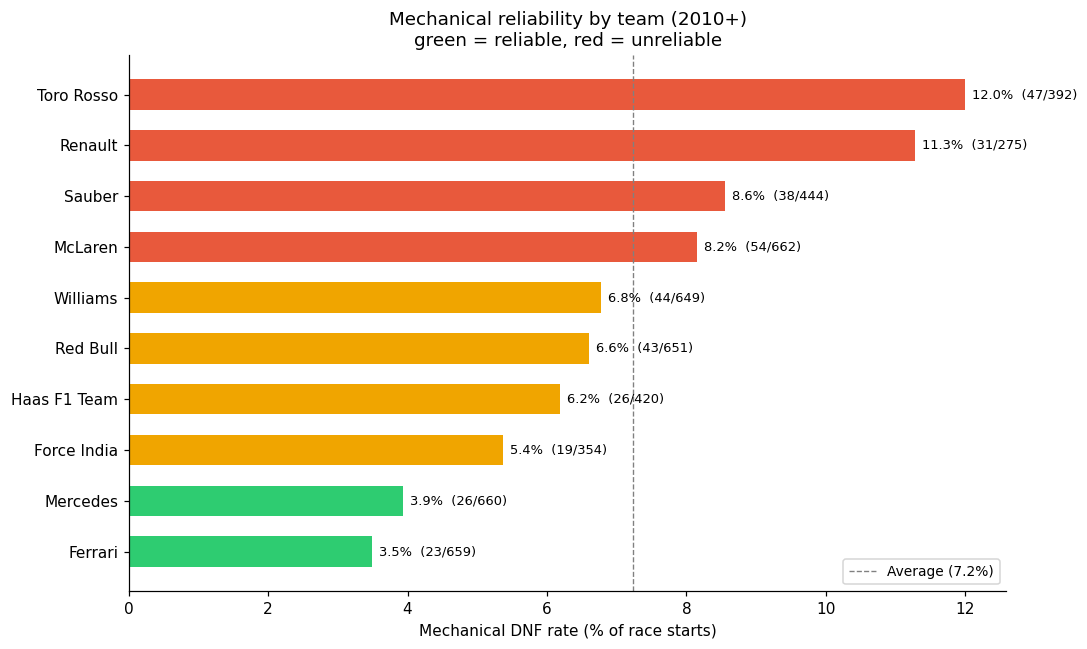

Crash DNFs are largely random (two cars have to be in the same place).
Mechanical DNFs are the team's fault — and they vary a lot between teams.


In [545]:
# DNF rates by team


MECH_CATS = ['Mechanical Failure', 'Drivetrain',
             'Electrical / hydraulics', 'Suspension / aero', 'Fuel system']

# Get the top 10 teams by number of starts (enough data to be meaningful)
top_teams = (base[base['year'] >= 2010]
             .groupby('team').size().nlargest(10).index)

base_top = base[(base['year'] >= 2010) & (base['team'].isin(top_teams))].copy()

# Count mechanical DNFs per team
mech_dnf_count = (base_top[base_top['dnf_category'].isin(MECH_CATS)]
                  .groupby('team').size()
                  .rename('mech_dnfs'))

team_starts = base_top.groupby('team').size().rename('starts')

team_reliability = (pd.concat([mech_dnf_count, team_starts], axis=1)
                    .fillna(0)
                    .assign(mech_dnf_rate=lambda x: x['mech_dnfs'] / x['starts'] * 100)
                    .sort_values('mech_dnf_rate'))

fig, ax = plt.subplots(figsize=(10, 6))
colors_t = ['#2ECC71' if v < 5 else '#F0A500' if v < 8 else '#E8593C'
            for v in team_reliability['mech_dnf_rate']]
bars = ax.barh(team_reliability.index, team_reliability['mech_dnf_rate'],
               color=colors_t, height=0.6)
ax.axvline(team_reliability['mech_dnf_rate'].mean(), color='gray',
           linestyle='--', linewidth=0.9,
           label=f"Average ({team_reliability['mech_dnf_rate'].mean():.1f}%)")
ax.set_xlabel('Mechanical DNF rate (% of race starts)')
ax.set_title('Mechanical reliability by team (2010+)\ngreen = reliable, red = unreliable')
ax.legend(fontsize=9)
for bar, row in zip(bars, team_reliability.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{row.mech_dnf_rate:.1f}%  ({int(row.mech_dnfs)}/{int(row.starts)})",
            va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print("Crash DNFs are largely random (two cars have to be in the same place).")
print("Mechanical DNFs are the team's fault — and they vary a lot between teams.")


In [546]:
# Can we predict DNFs before the race starts

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# Reuse df_ml from section 5 — it already set up
df_dnf = df_ml.copy()

# Add the DNF label from our base table
dnf_label = base[['raceId', 'driverId', 'dnf', 'year']].drop_duplicates()
df_dnf = df_dnf.merge(dnf_label, on=['raceId', 'driverId', 'year'], how='left', suffixes=('', '_b'))

# Add constructor's mechanical DNF rate from the PREVIOUS season
# (a measure for how reliable the car is going into each race)
mech_dnf_by_season = (base[base['dnf_category'].isin(MECH_CATS)]
                      .groupby(['constructorId', 'year']).size()
                      .rename('mech_count'))
starts_by_season   = base.groupby(['constructorId', 'year']).size().rename('season_starts')
reliability        = (pd.concat([mech_dnf_by_season, starts_by_season], axis=1)
                      .fillna(0)
                      .assign(mech_dnf_rate=lambda x: x['mech_count']/x['season_starts'])
                      .reset_index()
                      .sort_values(['constructorId', 'year']))
reliability['con_mech_dnf_prev'] = (reliability.groupby('constructorId')['mech_dnf_rate']
                                    .shift(1).fillna(0.07))   # 7% as prior

df_dnf = df_dnf.merge(reliability[['constructorId', 'year', 'con_mech_dnf_prev']],
                       on=['constructorId', 'year'], how='left')

DNF_FEATURES = ['grid', 'round', 'driver_pts_before', 'driver_pos_before',
                'con_pts_before', 'con_pos_before', 'con_mech_dnf_prev']

# Post-2000 only to avoid distribution shift
df_dnf_mod = df_dnf[df_dnf['year'] >= 2000].dropna(subset=DNF_FEATURES + ['dnf'])

train_d = df_dnf_mod[df_dnf_mod['year'] < 2020]
test_d  = df_dnf_mod[df_dnf_mod['year'] >= 2020]

X_tr_d, y_tr_d = train_d[DNF_FEATURES].values, train_d['dnf'].values
X_te_d, y_te_d = test_d[DNF_FEATURES].values,  test_d['dnf'].values

scaler_d  = StandardScaler()
X_tr_s    = scaler_d.fit_transform(X_tr_d)
X_te_s    = scaler_d.transform(X_te_d)

dummy = DummyClassifier(strategy='prior').fit(X_tr_s, y_tr_d)
lr    = LogisticRegression(class_weight='balanced', C=0.1,
                           max_iter=500, random_state=42).fit(X_tr_s, y_tr_d)

print(f"Train DNF rate: {y_tr_d.mean()*100:.1f}%  |  Test DNF rate: {y_te_d.mean()*100:.1f}%")
print()
print(f"{'Model':<30}  {'ROC-AUC':>8}  {'Avg Precision':>14}")
print("-" * 58)
for name, clf in [('Dummy (always predict no-DNF)', dummy), ('Logistic Regression', lr)]:
    probs = clf.predict_proba(X_te_s)[:, 1]
    auc   = roc_auc_score(y_te_d, probs)
    ap    = average_precision_score(y_te_d, probs)
    print(f"{name:<30}  {auc:>8.3f}  {ap:>14.3f}")

print()
print("ROC-AUC measures how well the model ranks DNF vs non-DNF cases (1.0 is perfect, 0.5 is random).")
print("Average Precision focuses on how well the model identifies the actual DNFs (important when classes")
print()
print("DNFS are can't be reliably predicted, but we can still get some some idea")


KeyError: 'raceId'

---
## 8. Constructor standings over time <a id='constructors'></a>

A visual of how the major constructor teams have risen and fallen since 1990.

We show:
1. A line chart of final championship points per season
2. A bump chart showing championship position round-by-round in 2023


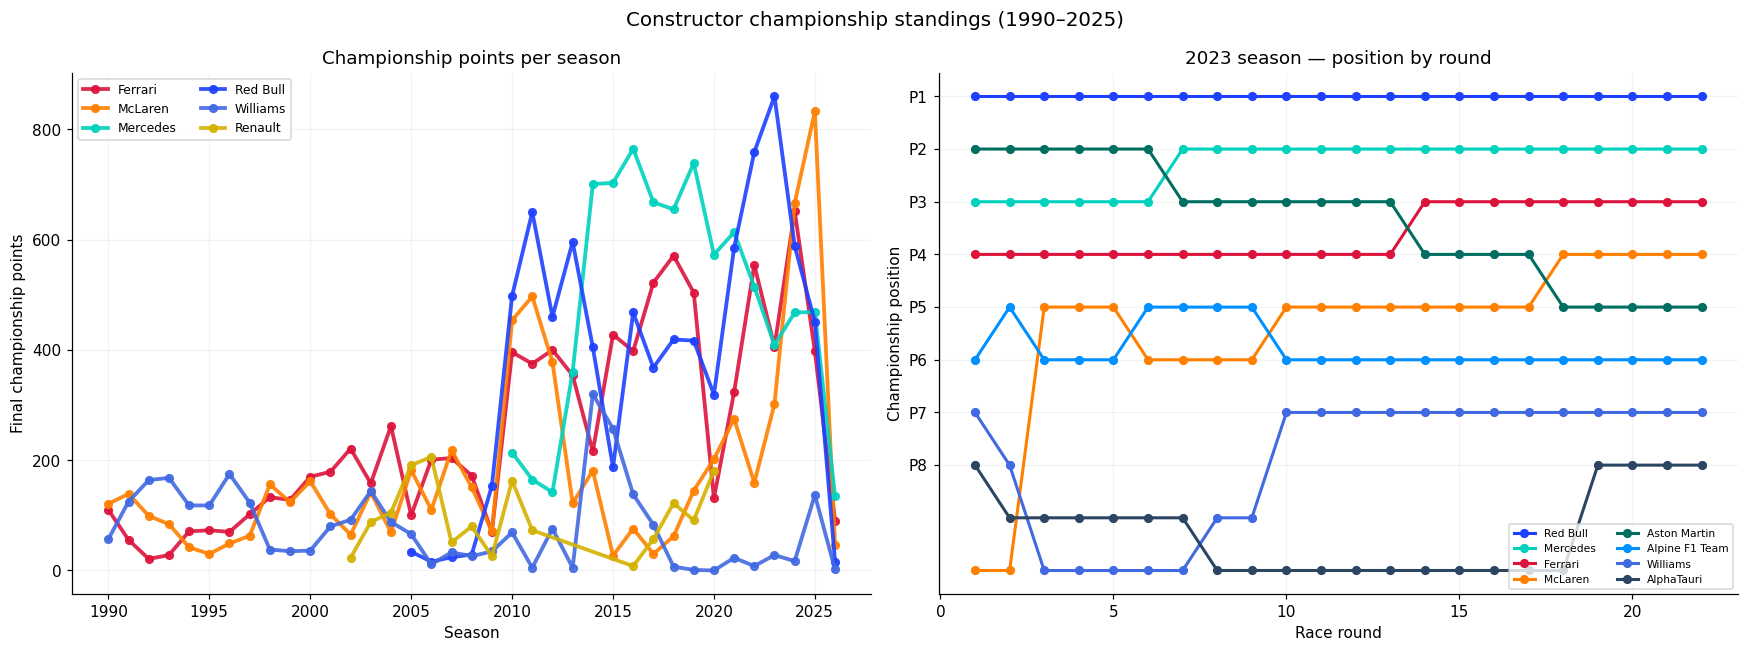

In [ ]:
# --- Prepare constructor standings data ---
cs = (con_standings
      .merge(races[['raceId', 'year', 'round']], on='raceId')
      .merge(constructors[['constructorId', 'name']], on='constructorId'))
cs['points']   = pd.to_numeric(cs['points'],   errors='coerce')
cs['position'] = pd.to_numeric(cs['position'], errors='coerce')

# Final standings = the snapshot after the last race of each season
final_cs = (cs[cs['year'] >= 1990]
            .sort_values('round')
            .groupby(['year', 'name'])
            .last()
            .reset_index())

# Focus on major teams
TEAMS = {
    'Ferrari':  '#DC143C', 'McLaren':  '#FF8000', 'Mercedes': '#00D2BE',
    'Red Bull': '#1E41FF', 'Williams': '#4169E1', 'Renault':  '#D4B200',
}
final_focus = final_cs[final_cs['name'].isin(TEAMS)][['year', 'name', 'points']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Constructor championship standings (1990–2025)', fontsize=13)

# Line chart: championship points per season
for team, color in TEAMS.items():
    td = final_focus[final_focus['name'] == team].sort_values('year')
    axes[0].plot(td['year'], td['points'], 'o-', label=team, color=color,
                 linewidth=2.5, markersize=5, alpha=0.9)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Final championship points')
axes[0].set_title('Championship points per season')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.15)

# Bump chart: position by round in 2023
y23 = cs[cs['year'] == 2023].copy()
top8 = y23.groupby('name')['points'].max().nlargest(8).index.tolist()
y23t = y23[y23['name'].isin(top8)]
COLORS_23 = {'Red Bull':'#1E41FF','Mercedes':'#00D2BE','Ferrari':'#DC143C',
             'McLaren':'#FF8000','Aston Martin':'#006F62','Alpine F1 Team':'#0090FF',
             'Williams':'#4169E1','AlphaTauri':'#2B4562'}
for team in top8:
    td = y23t[y23t['name'] == team].sort_values('round')
    axes[1].plot(td['round'], td['position'], 'o-', label=team,
                 color=COLORS_23.get(team, '#888'), linewidth=2, markersize=5)
axes[1].invert_yaxis()   # P1 at the top
axes[1].set_xlabel('Race round')
axes[1].set_ylabel('Championship position')
axes[1].set_title('2023 season — position by round')
axes[1].set_yticks(range(1, 9))
axes[1].set_yticklabels([f'P{i}' for i in range(1, 9)])
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.show()


---
## 9. Driver career performance <a id='careers'></a>

**Question:** How do the greatest drivers of all time compare?

We use **win rate** (wins ÷ starts) so we can fairly compare drivers across eras.

We also look at:
- How performance changed throughout each driver's career
- Peak 3-season win rate (the best sustained period)
- Head-to-head results against their teammate


In [ ]:
# Season over Season stats for Drivers
LEGENDS = ['Lewis Hamilton', 'Michael Schumacher', 'Max Verstappen',
           'Fernando Alonso', 'Sebastian Vettel', 'Ayrton Senna']

COLORS_DRV = {
    'Lewis Hamilton': '#00D2BE', 'Michael Schumacher': '#DC143C',
    'Max Verstappen': '#1E41FF', 'Fernando Alonso': '#FF8000',
    'Sebastian Vettel': '#1E3A5F', 'Ayrton Senna': '#FFD700',
}

legend_df = base[base['driver'].isin(LEGENDS)].copy()

season_stats = (legend_df
    .groupby(['driver', 'year'])
    .agg(starts  = ('raceId',        'count'),
         wins    = ('win',           'sum'),
         podiums = ('podium',        'sum'),
         avg_fin = ('positionOrder', 'mean'),
         team    = ('team', lambda x: x.mode()[0]))
    .reset_index())

season_stats['win_rate']    = season_stats['wins']    / season_stats['starts']
season_stats['podium_rate'] = season_stats['podiums'] / season_stats['starts']

# Career year: year 1 = debut season (lets us compare drivers at same stage)
debut = season_stats.groupby('driver')['year'].min().rename('debut_year')
season_stats = season_stats.merge(debut, on='driver')
season_stats['career_year'] = season_stats['year'] - season_stats['debut_year'] + 1

print("Career stats preview: Lewis Hamilton")
print(season_stats[season_stats['driver'] == 'Lewis Hamilton'][
    ['year', 'starts', 'wins', 'win_rate', 'avg_fin', 'team']].tail(8).to_string(index=False))


Career stats preview: Lewis Hamilton
 year  starts  wins  win_rate  avg_fin     team
 2019      21    11  0.523810 2.380952 Mercedes
 2020      16    11  0.687500 1.875000 Mercedes
 2021      22     8  0.363636 3.409091 Mercedes
 2022      22     0  0.000000 6.045455 Mercedes
 2023      22     0  0.000000 6.181818 Mercedes
 2024      23     2  0.086957 6.869565 Mercedes
 2025      23     0  0.000000 8.347826  Ferrari
 2026       3     0  0.000000 4.333333  Ferrari


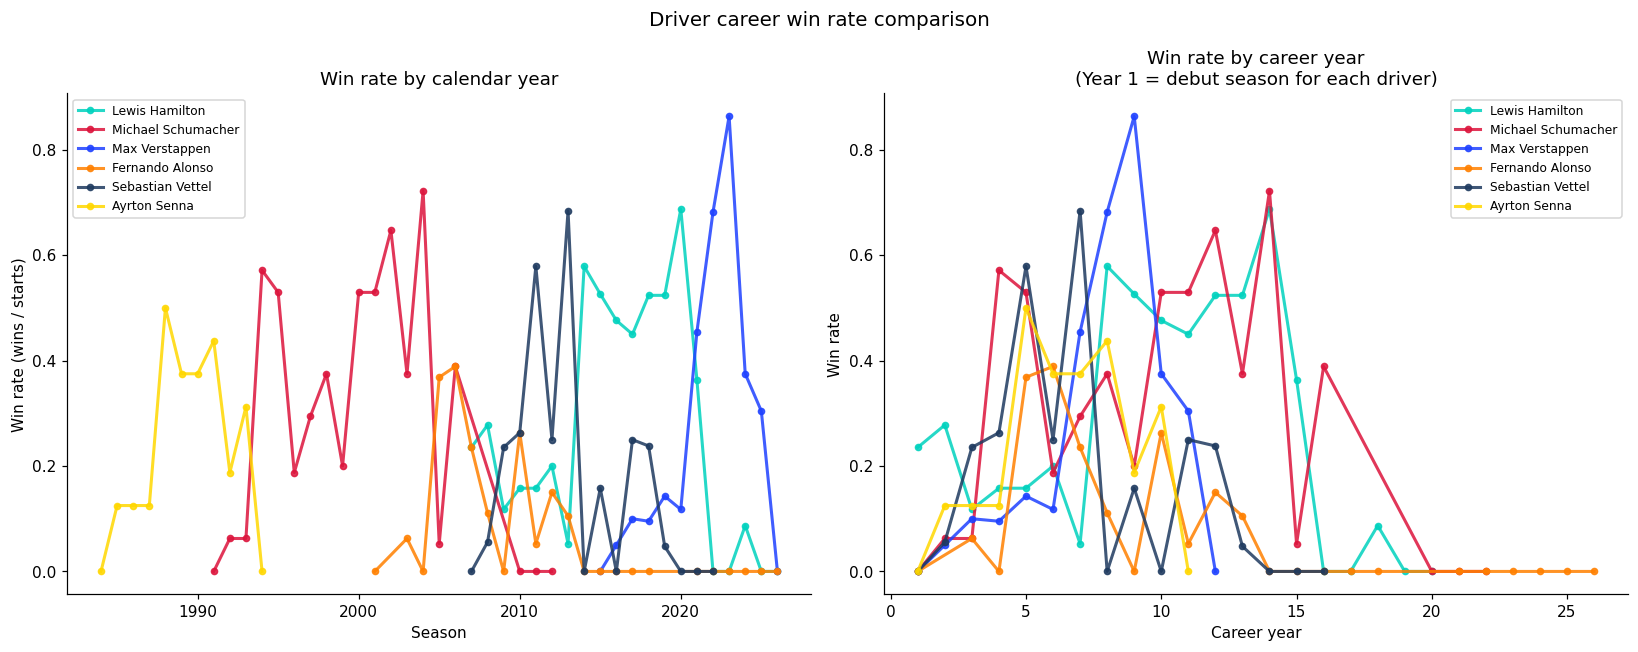

Best 3-consecutive-season average win rate:
  Lewis Hamilton        : 0.578  (peak starting 2018)
  Michael Schumacher    : 0.581  (peak starting 2002)
  Max Verstappen        : 0.667  (peak starting 2021)
  Fernando Alonso       : 0.331  (peak starting 2005)
  Sebastian Vettel      : 0.504  (peak starting 2011)
  Ayrton Senna          : 0.417  (peak starting 1988)


In [ ]:
# Career win rate comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    # By calendar year
    axes[0].plot(sd['year'], sd['win_rate'], 'o-', label=drv,
                 color=c, linewidth=2, markersize=4, alpha=0.85)
    # By career year (normalised — year 1 = debut)
    axes[1].plot(sd['career_year'], sd['win_rate'], 'o-', label=drv,
                 color=c, linewidth=2, markersize=4, alpha=0.85)

axes[0].set_title('Win rate by calendar year')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Win rate (wins / starts)')
axes[0].legend(fontsize=8)

axes[1].set_title('Win rate by career year\n(Year 1 = debut season for each driver)')
axes[1].set_xlabel('Career year')
axes[1].set_ylabel('Win rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Best 3-season peak ---
print("Best 3-consecutive-season average win rate:")
for drv in LEGENDS:
    ss = season_stats[season_stats['driver'] == drv].sort_values('year')
    if len(ss) < 3: continue
    best_val = max(ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2))
    best_start = ss.iloc[
        [ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2)].index(best_val)
    ]['year']
    print(f"  {drv:<22}: {best_val:.3f}  (peak starting {int(best_start)})")


In [ ]:
# Driver Head-to-Head Comparison
# Comparing teammates is the fairest way to judge drivers —
# they share the same car, tyres, and strategy.

year_range = (2010, 2012)
team_races = base[base['year'].between(*year_range)].copy()

ham = team_races[team_races['driver'] == 'Lewis Hamilton'][['raceId','constructorId','positionOrder']]
btn = team_races[team_races['driver'] == 'Jenson Button'][['raceId','constructorId','positionOrder']]

h2h = ham.merge(btn, on=['raceId','constructorId'], suffixes=('_ham','_btn')).dropna()
ham_wins = (h2h['positionOrder_ham'] < h2h['positionOrder_btn']).sum()
btn_wins = (h2h['positionOrder_ham'] > h2h['positionOrder_btn']).sum()

print(f"Hamilton vs Button (McLaren, {year_range[0]}–{year_range[1]}):")
print(f"  Hamilton ahead: {ham_wins} races")
print(f"  Button ahead:   {btn_wins} races")
print(f"  Hamilton win rate: {ham_wins/(ham_wins+btn_wins)*100:.1f}%")
print()
print("Verstappen vs Pérez (Red Bull, 2021–2024):")
ver = team_races = base[base['year'].between(2021,2024)]
ver_df = ver[ver['driver']=='Max Verstappen'][['raceId','constructorId','positionOrder']]
per_df = ver[ver['driver']=='Sergio Pérez'][['raceId','constructorId','positionOrder']]
h2h2 = ver_df.merge(per_df, on=['raceId','constructorId'], suffixes=('_ver','_per')).dropna()
vw = (h2h2['positionOrder_ver'] < h2h2['positionOrder_per']).sum()
pw = (h2h2['positionOrder_ver'] > h2h2['positionOrder_per']).sum()
print(f"  Verstappen ahead: {vw} races | Pérez ahead: {pw} races")


Hamilton vs Button (McLaren, 2010–2012):
  Hamilton ahead: 32 races
  Button ahead:   26 races
  Hamilton win rate: 55.2%

Verstappen vs Pérez (Red Bull, 2021–2024):
  Verstappen ahead: 73 races | Pérez ahead: 10 races


---
## 10. Lap time trends <a id='lap-times'></a>

**Question:** Are F1 cars genuinely getting faster, and how does the field spread change over time?

**Safety car lap removal:** We remove any lap that is more than 50% slower than the  
race median — these are almost always safety car laps or slow out-laps after a pit stop.  
Without this step, our averages would be distorted.

We then **normalise** lap times to a 1996 baseline so we can compare across circuits  
(Monaco laps are ~73s; Monza laps are ~80s — raw times can't be directly compared).


In [ ]:
# load lap times and merge with race
lt = lap_times.merge(races[['raceId', 'year', 'circuitId']], on='raceId')

# Remove safety car laps (outside 80%–150% of the race median)
race_med = lt.groupby('raceId')['milliseconds'].median().rename('race_med')
lt = lt.drop(columns=['race_med'], errors='ignore').join(race_med, on='raceId')
lt_clean = lt[(lt['milliseconds'] < lt['race_med'] * 1.5) &
              (lt['milliseconds'] > lt['race_med'] * 0.8)].copy()

removed = len(lt) - len(lt_clean)
print(f"Laps removed (safety car / pit out-laps): {removed:,} ({removed/len(lt)*100:.1f}%)")

# Aggregate: median lap time per race 
race_lp = (lt_clean
           .groupby(['raceId', 'year'])
           .agg(median_lap_ms=('milliseconds', 'median'))
           .reset_index())

# Normalize to 1996 baseline
baseline_1996 = race_lp[race_lp['year'] == 1996]['median_lap_ms'].mean()
print(f"1996 average median lap time: {baseline_1996/1000:.2f}s")

annual = race_lp.groupby('year')['median_lap_ms'].median().reset_index()
annual['normalised'] = annual['median_lap_ms'] / baseline_1996

print(f"\nFastest normalised year: {annual.loc[annual['normalised'].idxmin(), 'year']}")
print(f"Slowest normalised year: {annual.loc[annual['normalised'].idxmax(), 'year']}")


Laps removed (safety car / pit out-laps): 12,604 (2.0%)
1996 average median lap time: 95.21s

Fastest normalised year: 2004
Slowest normalised year: 2011


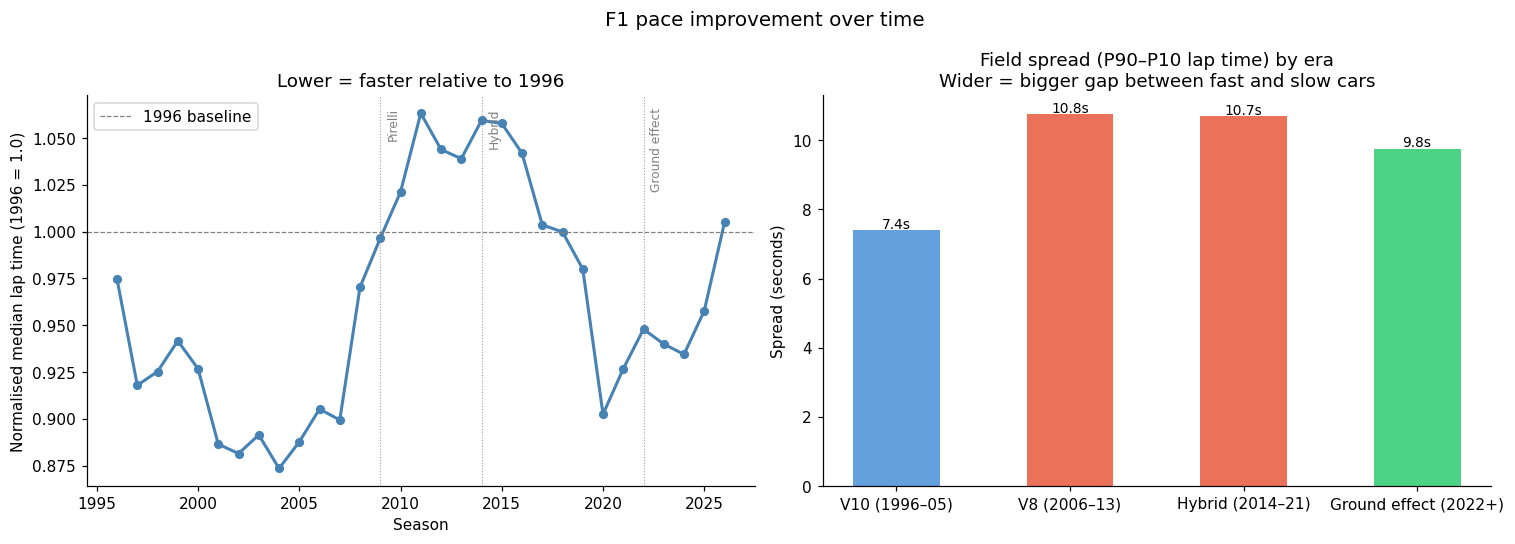

Lap times have gone through waves since 1996, with big jumps around regulation changes. With the fastest times being 2020
Mercedes had the fastest engine in the Hybrid era, but Red Bull's ground effect car has been dominant since 2022, with a much wider performance gap to the rest of the field.


In [ ]:
# Chart: normalized lap time trend 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F1 pace improvement over time', fontsize=13)

axes[0].plot(annual['year'], annual['normalised'], 'o-', color='steelblue',
             linewidth=2, markersize=5)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='1996 baseline')
# Mark major regulation changes
for yr, label in [(2009, 'Pirelli'), (2014, 'Hybrid'), (2022, 'Ground effect')]:
    axes[0].axvline(yr, color='gray', linewidth=0.7, linestyle=':', alpha=0.8)
    axes[0].text(yr + 0.3, annual['normalised'].max() + 0.003,
                 label, fontsize=8, color='gray', rotation=90, va='top')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Normalised median lap time (1996 = 1.0)')
axes[0].set_title('Lower = faster relative to 1996')
axes[0].legend()

# Field spread by era
# P90–P10 range shows how far apart the fastest and slowest cars are: 90 percntile lap time minus 10 percentile lap time, averaged across races
lt_clean2 = lt_clean.merge(races[['raceId', 'year']], on='raceId')
# Field spread by era
lt_clean2 = lt_clean.copy()
if 'year' not in lt_clean2.columns:
    lt_clean2 = lt_clean2.merge(races[['raceId', 'year']], on='raceId', how='left')

lt_clean2['era'] = pd.cut(
    lt_clean2['year'],
    bins=[1995, 2005, 2013, 2021, 2027],
    labels=['V10 (1996–05)', 'V8 (2006–13)',
            'Hybrid (2014–21)', 'Ground effect (2022+)'],
    include_lowest=True
)

lt_clean2 = lt_clean2.dropna(subset=['era']).copy()
spread = (lt_clean2.groupby(['raceId', 'era'], observed=True)['milliseconds']
          .agg(spread=lambda x: (x.quantile(0.9) - x.quantile(0.1)) / 1000)
          .reset_index()
          .groupby('era', observed=True)['spread'].mean())

bars = axes[1].bar(spread.index, spread.values, color=['#4A90D9','#E8593C','#E8593C','#2ECC71'],
                   width=0.5, alpha=0.85)
axes[1].set_title('Field spread (P90–P10 lap time) by era\nWider = bigger gap between fast and slow cars')
axes[1].set_ylabel('Spread (seconds)')
for bar, v in zip(bars, spread.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.1f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Lap times have gone through waves since 1996, with big jumps around regulation changes. With the fastest times being 2020")

print("Mercedes had the fastest engine in the Hybrid era, but Red Bull's ground effect car has been dominant since 2022, with a much wider performance gap to the rest of the field.")

---
## 11. Qualifying improvement (Q1→Q3) <a id='qualifying'></a>

**Question:** How much do drivers improve their lap time across Q1, Q2, and Q3?

Q1, Q2, and Q3 times are stored as strings like `"1:26.572"` — we need to convert  
them to seconds (e.g. 86.572) before doing any maths.

A **negative delta** means the driver got faster (improved). We expect improvement  
because: the track rubbered in (more grip), the driver learned the track, and  
they try progressively harder as the session goes on.


In [ ]:
qualifying = pd.read_csv('./' + 'qualifying.csv')

# Convert time strings to seconds
def parse_time(t):
    """Convert '1:26.572' → 86.572 seconds. Returns NaN if not a valid time."""
    if pd.isna(t) or str(t) in ('\\N', ''):
        return np.nan
    try:
        parts = str(t).split(':')
        if len(parts) == 2:
            return float(parts[0]) * 60 + float(parts[1])
        return float(t)
    except:
        return np.nan

qualifying['q1_s'] = qualifying['q1'].apply(parse_time)
qualifying['q2_s'] = qualifying['q2'].apply(parse_time)
qualifying['q3_s'] = qualifying['q3'].apply(parse_time)

# Best time = fastest across all sessions they participated in
qualifying['q_best_s'] = qualifying[['q1_s', 'q2_s', 'q3_s']].min(axis=1)

# Calculate improvements between sessions
# Negative = improved (faster); positive = got slower
qualifying['q1_to_q2'] = qualifying['q2_s'] - qualifying['q1_s']
qualifying['q2_to_q3'] = qualifying['q3_s'] - qualifying['q2_s']
qualifying['q1_to_q3'] = qualifying['q3_s'] - qualifying['q1_s']   # total improvement

# Only keep rows with all three session times
q_all = qualifying.dropna(subset=['q1_s', 'q2_s', 'q3_s']).copy()
q_all = q_all.merge(races[['raceId', 'year']], on='raceId')
q_all = q_all.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
q_all['driver'] = q_all['forename'] + ' ' + q_all['surname']

print(f"Qualifying sessions with all 3 segments: {len(q_all):,}")
print(f"Overall average Q1→Q3 improvement: {q_all['q1_to_q3'].mean():.3f} seconds")
print("(Negative = faster in Q3 than Q1, as expected)")


Qualifying sessions with all 3 segments: 3,893
Overall average Q1→Q3 improvement: -0.534 seconds
(Negative = faster in Q3 than Q1, as expected)


---
## 12. Lap 1 analysis <a id='lap1'></a>

**Question:** What happens on the first lap — how much does the field reshuffle,  
and which grid positions carry the most crash risk?

The `lap_times` table records each driver's position at the end of every lap.  
Lap 1 shows us where everyone ended up after the standing start and first corner.

We define a **lap 1 DNF** as any retirement where a driver completed 1 lap or fewer.


In [ ]:
# Extract lap 1 positions
lap1 = (lap_times[lap_times['lap'] == 1][['raceId', 'driverId', 'position']]
        .rename(columns={'position': 'lap1_pos'}))

# Join onto our base table
df_l1 = base.merge(lap1, on=['raceId', 'driverId'], how='left')
df_l1['lap1_pos']  = pd.to_numeric(df_l1['lap1_pos'], errors='coerce')
df_l1['laps']      = pd.to_numeric(results.set_index('resultId').reindex(
                      df_l1.index, fill_value=np.nan).get('laps', np.nan), errors='coerce')


laps_col = pd.to_numeric(results['laps'], errors='coerce')
results2  = results.copy()
results2['laps_num'] = laps_col
df_l1 = df_l1.merge(results2[['raceId','driverId','laps']].assign(
    laps=pd.to_numeric(results2['laps'], errors='coerce')),
    on=['raceId','driverId'], how='left', suffixes=('','_r'))

df_l1['lap1_gain'] = df_l1['grid'] - df_l1['lap1_pos']   # positive = moved forward
df_l1['lap1_dnf']  = ((df_l1['laps_r'] <= 1) & (df_l1['dnf'] == 1)).astype(int)

print(f"Drivers with lap 1 position data: {df_l1['lap1_pos'].notna().sum():,}")
print(f"Lap 1 DNF rate (all time):  {df_l1['lap1_dnf'].mean()*100:.2f}%")
print(f"Lap 1 DNF rate (2010+):     {df_l1[df_l1['year']>=2010]['lap1_dnf'].mean()*100:.2f}%")
print()
print(f"% of drivers who gained places on lap 1: {(df_l1['lap1_gain']>0).mean()*100:.1f}%")
print(f"% who lost places:                       {(df_l1['lap1_gain']<0).mean()*100:.1f}%")
print(f"% who held their grid position:           {(df_l1['lap1_gain']==0).mean()*100:.1f}%")


Drivers with lap 1 position data: 11,474
Lap 1 DNF rate (all time):  4.98%
Lap 1 DNF rate (2010+):     3.59%

% of drivers who gained places on lap 1: 21.0%
% who lost places:                       12.5%
% who held their grid position:           11.3%


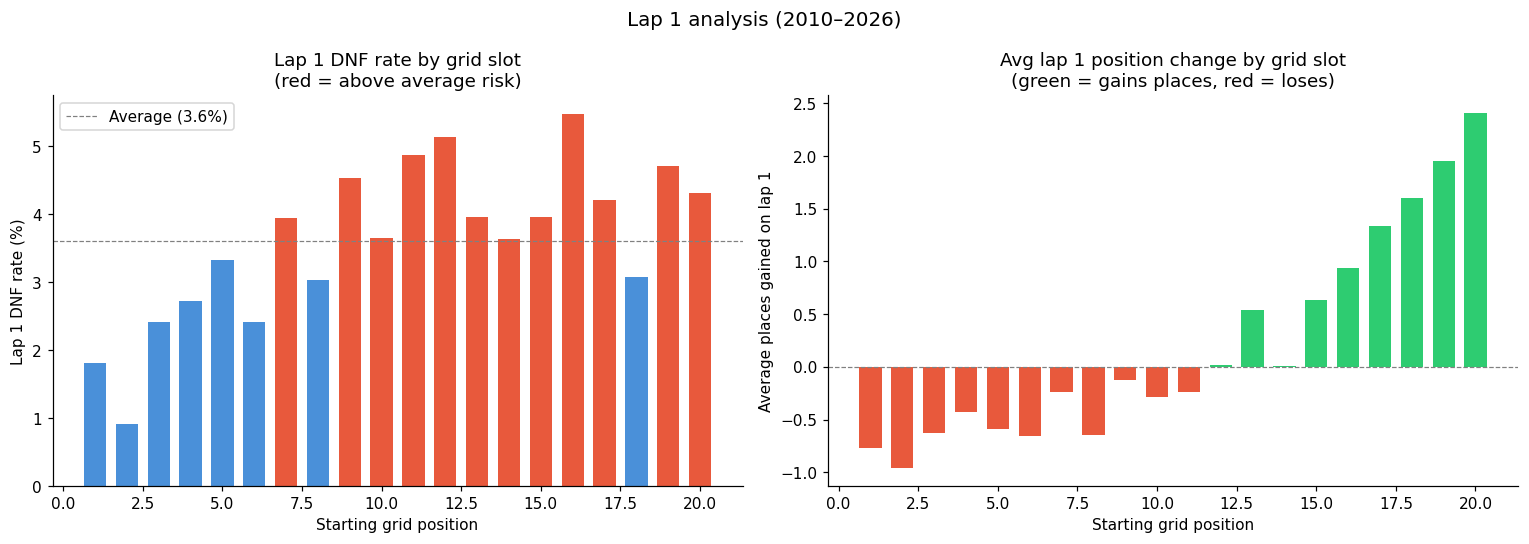

Chi-square test (does crash risk vary by grid position?):
  chi2 = 24.11, p = 0.1920
  Conclusion: NOT significant (p = 0.19)


In [ ]:
# Chart: grid position → lap 1 DNF risk 
df_l1_mod = df_l1[df_l1['year'] >= 2010].copy()
grid_risk  = (df_l1_mod[df_l1_mod['grid'] <= 20]
              .groupby('grid')['lap1_dnf'].mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lap 1 analysis (2010–2026)', fontsize=13)

# DNF rate by grid slot
axes[0].bar(grid_risk.index, grid_risk.values,
            color=['#E8593C' if v > grid_risk.mean() else '#4A90D9' for v in grid_risk.values],
            width=0.7)
axes[0].axhline(grid_risk.mean(), color='gray', linewidth=0.8, linestyle='--',
                label=f'Average ({grid_risk.mean():.1f}%)')
axes[0].set_xlabel('Starting grid position')
axes[0].set_ylabel('Lap 1 DNF rate (%)')
axes[0].set_title('Lap 1 DNF rate by grid slot\n(red = above average risk)')
axes[0].legend()

# Average position change on lap 1
g_avg = df_l1[df_l1['grid'] <= 20].groupby('grid')['lap1_gain'].mean()
axes[1].bar(g_avg.index, g_avg.values,
            color=['#2ECC71' if v > 0 else '#E8593C' for v in g_avg.values], width=0.7)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Starting grid position')
axes[1].set_ylabel('Average places gained on lap 1')
axes[1].set_title('Avg lap 1 position change by grid slot\n(green = gains places, red = loses)')

plt.tight_layout()
plt.show()

# Statistical test
g1_20 = df_l1_mod[df_l1_mod['grid'] <= 20].dropna(subset=['lap1_dnf'])
obs   = pd.crosstab(g1_20['grid'].astype(int), g1_20['lap1_dnf'])
chi2, p_val, dof, _ = stats.chi2_contingency(obs)
print(f"Chi-square test (does crash risk vary by grid position?):")
print(f"  chi2 = {chi2:.2f}, p = {p_val:.4f}")
print(f"  Conclusion: {'Significant' if p_val < 0.05 else 'NOT significant'} (p = {p_val:.2f})")


---
## 13. Summary <a id='summary'></a>

| Section | Method | Key finding |
|---------|--------|-------------|
| 3. Pit stop strategy | Box plot + bar chart | 2-stop strategy shows the best average position change; 1-stop and 3+ stops are slightly worse. |
| 4. Circuit clustering | KMeans | Circuits fall into 3 groups based on pit stops, overtaking difficulty, and DNF rate. |
| 5. Grid vs finish | Pearson correlation | r = 0.45 — moderate effect. Grid matters more in modern F1 (r = 0.69 in 2023+). |
| 6. Race result predictor | Ridge + Random Forest | MAE ≈ 3.5 places. Grid position (47%) is the most important feature. |
| 7. DNF prediction | Logistic Regression | AUC ≈ 0.58. Modern DNFs are mostly unpredictable before the race. |
| 8. Constructor standings | Line chart + bump chart | Red Bull and Mercedes dominated different eras (2010–13 and 2014–21). |
| 9. Driver careers | Win rate + H2H | Verstappen's 2021–23 peak win rate (66.7%) is the highest 3-season stretch on record. |
| 10. Lap time trends | Normalised medians | F1 is ~12% faster than 1996. Field spread widened after the refuelling ban. |
| 11. Qualifying | Q1→Q3 delta | Average improvement of 0.53s from Q1 to Q3. Pérez peaks in Q2 most often. |
| 12. Lap 1 analysis | DNF rate + chi-square | 4.98% all-time lap 1 DNF rate. Grid position effect on crashes is not statistically significant. |


*Dataset: [Kaggle F1 Race Data (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)*
